# Introduction to Linear Regression in Python
### CFA Level 1 Quantitative Methods | Applied to Real Market Scenarios

---

## The Scenario

You are a quantitative analyst at an equity long/short fund.

Your PM comes to you with three questions:

> 1. "How much of our portfolio's daily moves can be explained
>     by the market? What is our beta?"

> 2. "We think gold is a hedge against equity drawdowns.
>     Can you quantify this relationship?"

> 3. "Our risk model assumes a linear relationship between
>     our fund and the benchmark. Is that assumption valid?"

Every one of these is a **linear regression** problem.

Regression is the backbone of quantitative finance.
Factor models, beta estimation, alpha generation,
risk decomposition — all of it starts here.

This notebook builds OLS regression from scratch,
tests every assumption, and applies it to real market data
to answer every question on the PM's list.

**Data source:** Financial Modeling Prep (FMP) API

## Setup

We will use the following libraries:

- `requests` — to pull data from FMP API
- `pandas` — for data manipulation
- `numpy` — for mathematical operations
- `matplotlib` — for visualizations
- `scipy` — for statistical tests
- `statsmodels` — for OLS regression and diagnostics

In [8]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.stats.diagnostic as smd
import warnings
from dotenv import load_dotenv
from statsmodels.stats.stattools import durbin_watson
import os

load_dotenv()
warnings.filterwarnings('ignore')

FMP_KEY = os.getenv("FMP_KEY")

# Plot styling
plt.rcParams['figure.facecolor'] = '#0D1117'
plt.rcParams['axes.facecolor']   = '#161B22'
plt.rcParams['axes.edgecolor']   = '#30363D'
plt.rcParams['text.color']       = '#E6EDF3'
plt.rcParams['axes.labelcolor']  = '#E6EDF3'
plt.rcParams['xtick.color']      = '#8B949E'
plt.rcParams['ytick.color']      = '#8B949E'
plt.rcParams['grid.color']       = '#21262D'
plt.rcParams['grid.linestyle']   = '--'
plt.rcParams['grid.alpha']       = 0.5

print("Libraries loaded successfully")
print("FMP Key loaded ✓" if FMP_KEY else "FMP Key missing ✗")

Libraries loaded successfully
FMP Key loaded ✓


## 1. Pulling Real Market Data

We pull 5 years of daily returns for four assets:

- **QQQ** — Nasdaq 100 (our "fund" proxy)
- **SPY** — S&P 500 (market benchmark)
- **GLD** — Gold (hedge asset)
- **TLT** — 20+ Year Treasury (bonds)

**The regression framework:**

$$R_{fund} = \alpha + \beta \cdot R_{market} + \varepsilon$$

Where:
- $\alpha$ (alpha) — return unexplained by the market
- $\beta$ (beta) — sensitivity to market moves
- $\varepsilon$ — residual error

This is the **Capital Asset Pricing Model (CAPM)** regression —
the most important single equation in finance.

In [2]:
# =============================================================================
# CELL 5 — Pull Market Data from FMP
# =============================================================================

def get_prices(ticker, api_key, from_date="2019-01-01", to_date="2024-01-01"):
    url = "https://financialmodelingprep.com/stable/historical-price-eod/full"
    params = {"symbol": ticker, "from": from_date, "to": to_date, "apikey": api_key}
    response = requests.get(url, params=params)
    data = response.json()
    if isinstance(data, list) and len(data) > 0:
        df = pd.DataFrame(data)
    elif isinstance(data, dict) and "historical" in data:
        df = pd.DataFrame(data["historical"])
    else:
        return None
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date").sort_index()
    return df["close"]

tickers = ["QQQ", "SPY", "GLD", "TLT"]

print("Pulling market data from FMP...")
prices = pd.DataFrame()
for ticker in tickers:
    px = get_prices(ticker, FMP_KEY)
    if px is not None:
        prices[ticker] = px
        print(f"  ✓ {ticker} — {len(px)} days loaded")

returns = np.log(prices / prices.shift(1)).dropna()

print(f"\nPeriod: {returns.index[0].date()} → {returns.index[-1].date()}")
print(f"Observations: {len(returns)} trading days")

print(f"\n{'='*55}")
print("SUMMARY STATISTICS")
print(f"{'='*55}")
print(f"\n  {'Asset':<8} {'Ann. Return':>13} {'Ann. Vol':>10} {'Sharpe':>8}")
print(f"  {'-'*42}")
for ticker in tickers:
    r       = returns[ticker].dropna()
    ann_ret = r.mean() * 252
    ann_vol = r.std(ddof=1) * np.sqrt(252)
    sharpe  = ann_ret / ann_vol
    print(f"  {ticker:<8} {ann_ret:>13.2%} {ann_vol:>10.2%} {sharpe:>8.4f}")
print(f"{'='*55}")

Pulling market data from FMP...
  ✓ QQQ — 1258 days loaded
  ✓ SPY — 1258 days loaded
  ✓ GLD — 1258 days loaded
  ✓ TLT — 1258 days loaded

Period: 2019-01-03 → 2023-12-29
Observations: 1257 trading days

SUMMARY STATISTICS

  Asset      Ann. Return   Ann. Vol   Sharpe
  ------------------------------------------
  QQQ             19.49%     25.50%   0.7646
  SPY             12.87%     21.16%   0.6080
  GLD              9.11%     14.95%   0.6097
  TLT             -4.24%     17.62%  -0.2404


## 2. OLS Regression from Scratch

**Ordinary Least Squares (OLS)** finds the line that minimises
the sum of squared residuals:

$$\min_{\alpha, \beta} \sum_{t=1}^{T} \varepsilon_t^2 = \min_{\alpha, \beta} \sum_{t=1}^{T} (R_{fund,t} - \alpha - \beta R_{market,t})^2$$

The closed-form solution:

$$\hat{\beta} = \frac{\sum(R_{market} - \bar{R}_{market})(R_{fund} - \bar{R}_{fund})}{\sum(R_{market} - \bar{R}_{market})^2} = \frac{Cov(R_{fund}, R_{market})}{Var(R_{market})}$$

$$\hat{\alpha} = \bar{R}_{fund} - \hat{\beta} \cdot \bar{R}_{market}$$

We implement this from scratch, then verify with `statsmodels`.

**The PM's first question:**

> "How much of QQQ's daily moves can be explained
> by the S&P 500? What is our beta?"

OLS REGRESSION — QQQ on SPY (2019–2023)

  Model: R_QQQ = α + β × R_SPY + ε

  Parameter        Estimate   Std Error    t-stat    p-value
  --------------------------------------------------------
  Alpha (α)        0.000201    0.000166    1.2096     0.2267
  Beta (β)         1.120792    0.012481   89.8034     0.0000

  GOODNESS OF FIT
  ─────────────────────────────────────────────
  R²:               0.865338  (86.53% of variance explained)
  Adjusted R²:      0.865231
  Residual SE:      0.005896  (0.5896%/day)
  F-statistic:      8064.6590  (p=0.000000)

  STATSMODELS VERIFICATION
  ─────────────────────────────────────────────
  α = 0.000201  (match: ✓)
  β = 1.120792  (match: ✓)
  R²= 0.865338  (match: ✓)

  ANSWER TO THE PM
  Beta = 1.1208
  → QQQ moves 1.12x the S&P 500 on average.
  → A 1% SPY move implies a 1.12% QQQ move.
  → QQQ is more volatile than the market.

  Alpha = 0.000201 (5.0726% annualised)
  → Positive alpha: QQQ outperforms
    the market on a risk-adjusted ba

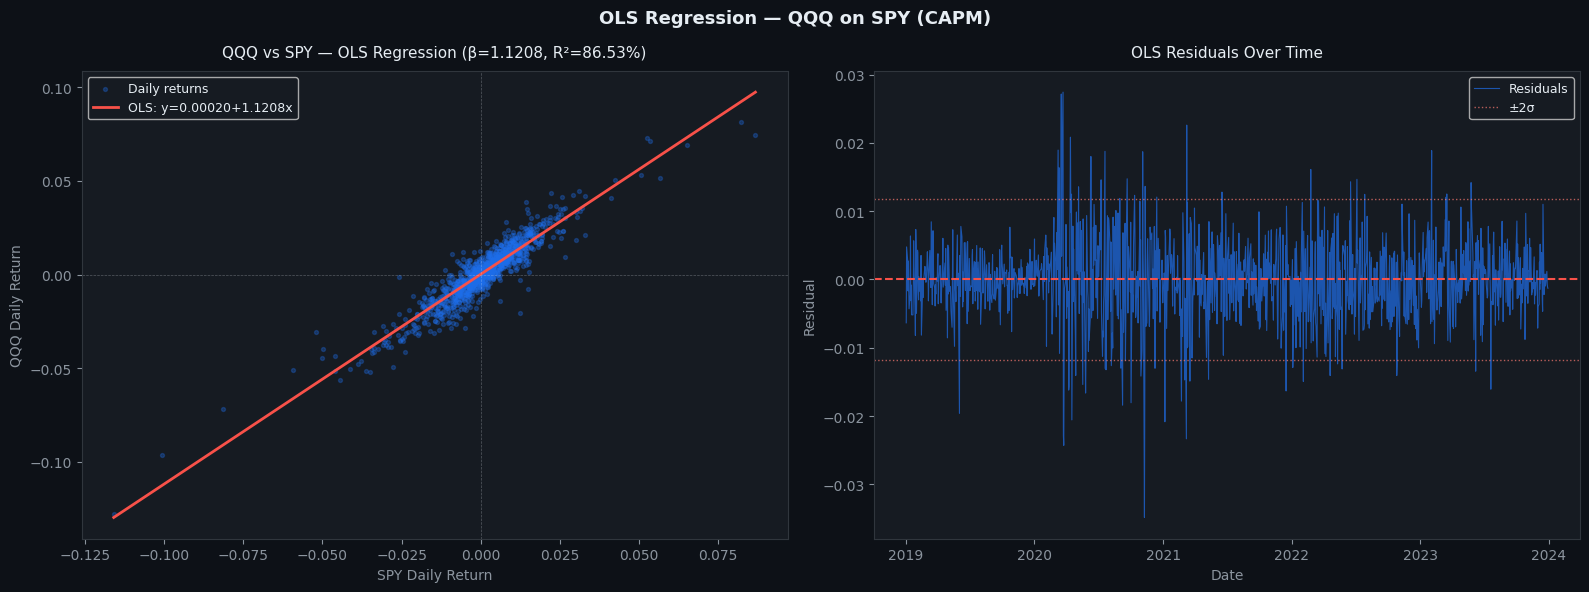

In [4]:
# =============================================================================
# CELL 7 — OLS Regression from Scratch: QQQ on SPY
# =============================================================================

y = returns["QQQ"].values  # dependent variable — our "fund"
x = returns["SPY"].values  # independent variable — market benchmark
n = len(y)

# ── OLS FROM SCRATCH ──────────────────────────────────────────────────────────
x_bar = x.mean()
y_bar = y.mean()

# Beta — covariance / variance
cov_xy  = np.sum((x - x_bar) * (y - y_bar)) / (n - 1)
var_x   = np.sum((x - x_bar)**2) / (n - 1)
beta    = cov_xy / var_x

# Alpha
alpha   = y_bar - beta * x_bar

# Fitted values and residuals
y_hat   = alpha + beta * x
resid   = y - y_hat

# ── GOODNESS OF FIT ───────────────────────────────────────────────────────────
# R-squared — proportion of variance explained
ss_tot  = np.sum((y - y_bar)**2)
ss_res  = np.sum(resid**2)
ss_reg  = ss_tot - ss_res
r2      = ss_reg / ss_tot

# Adjusted R-squared
r2_adj  = 1 - (1 - r2) * (n - 1) / (n - 2)

# ── STANDARD ERRORS ───────────────────────────────────────────────────────────
# Residual standard error
s2      = ss_res / (n - 2)
s       = np.sqrt(s2)

# SE of beta
se_beta = np.sqrt(s2 / ((n - 1) * var_x))

# SE of alpha
se_alpha = np.sqrt(s2 * (1/n + x_bar**2 / ((n-1) * var_x)))

# ── t-STATISTICS AND p-VALUES ─────────────────────────────────────────────────
t_beta  = beta  / se_beta
t_alpha = alpha / se_alpha
p_beta  = 2 * (1 - stats.t.cdf(abs(t_beta),  df=n-2))
p_alpha = 2 * (1 - stats.t.cdf(abs(t_alpha), df=n-2))

# ── F-STATISTIC ───────────────────────────────────────────────────────────────
f_stat  = (ss_reg / 1) / (ss_res / (n - 2))
p_f     = 1 - stats.f.cdf(f_stat, dfn=1, dfd=n-2)

# ── VERIFY WITH STATSMODELS ───────────────────────────────────────────────────
X_sm    = sm.add_constant(x)
model   = sm.OLS(y, X_sm).fit()

# ── PRINT RESULTS ─────────────────────────────────────────────────────────────
print(f"{'='*62}")
print("OLS REGRESSION — QQQ on SPY (2019–2023)")
print(f"{'='*62}")

print(f"""
  Model: R_QQQ = α + β × R_SPY + ε
""")

print(f"  {'Parameter':<12} {'Estimate':>12} {'Std Error':>11} "
      f"{'t-stat':>9} {'p-value':>10}")
print(f"  {'-'*56}")
print(f"  {'Alpha (α)':<12} {alpha:>12.6f} {se_alpha:>11.6f} "
      f"{t_alpha:>9.4f} {p_alpha:>10.4f}")
print(f"  {'Beta (β)':<12} {beta:>12.6f} {se_beta:>11.6f} "
      f"{t_beta:>9.4f} {p_beta:>10.4f}")

print(f"\n  GOODNESS OF FIT")
print(f"  {'─'*45}")
print(f"  R²:               {r2:.6f}  ({r2:.2%} of variance explained)")
print(f"  Adjusted R²:      {r2_adj:.6f}")
print(f"  Residual SE:      {s:.6f}  ({s:.4%}/day)")
print(f"  F-statistic:      {f_stat:.4f}  (p={p_f:.6f})")

print(f"\n  STATSMODELS VERIFICATION")
print(f"  {'─'*45}")
print(f"  α = {model.params[0]:.6f}  (match: {'✓' if abs(model.params[0]-alpha)<1e-8 else '✗'})")
print(f"  β = {model.params[1]:.6f}  (match: {'✓' if abs(model.params[1]-beta)<1e-8 else '✗'})")
print(f"  R²= {model.rsquared:.6f}  (match: {'✓' if abs(model.rsquared-r2)<1e-8 else '✗'})")

print(f"""
  ANSWER TO THE PM
  Beta = {beta:.4f}
  → QQQ moves {beta:.2f}x the S&P 500 on average.
  → A 1% SPY move implies a {beta:.2f}% QQQ move.
  → QQQ is {'more' if beta > 1 else 'less'} volatile than the market.

  Alpha = {alpha:.6f} ({alpha*252:.4%} annualised)
  → {'Positive' if alpha > 0 else 'Negative'} alpha: QQQ {'outperforms' if alpha > 0 else 'underperforms'}
    the market on a risk-adjusted basis.
  → p-value = {p_alpha:.4f} — alpha is {'significant' if p_alpha < 0.05 else 'NOT significant'} at 5%.

  R² = {r2:.2%}
  → {r2:.2%} of QQQ's daily variance is explained by SPY.
  → The remaining {1-r2:.2%} is idiosyncratic (stock-specific) risk.
""")
print(f"{'='*62}")

# ── PLOT ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0D1117')

# Panel 1 — Scatter plot with regression line
ax1 = axes[0]
ax1.scatter(x, y, color='#1F6FEB', alpha=0.3, s=8, label='Daily returns')
x_line = np.linspace(x.min(), x.max(), 100)
ax1.plot(x_line, alpha + beta * x_line, color='#F85149',
         linewidth=2, label=f'OLS: y={alpha:.5f}+{beta:.4f}x')
ax1.axhline(0, color='#E6EDF3', linewidth=0.5, linestyle='--', alpha=0.3)
ax1.axvline(0, color='#E6EDF3', linewidth=0.5, linestyle='--', alpha=0.3)
ax1.set_title(f'QQQ vs SPY — OLS Regression (β={beta:.4f}, R²={r2:.2%})',
              color='#E6EDF3', fontsize=11, pad=10)
ax1.set_xlabel('SPY Daily Return', color='#8B949E')
ax1.set_ylabel('QQQ Daily Return', color='#8B949E')
ax1.set_facecolor('#161B22')
ax1.legend(fontsize=9, facecolor='#161B22', labelcolor='#E6EDF3')
for spine in ax1.spines.values():
    spine.set_edgecolor('#30363D')

# Panel 2 — Residuals over time
ax2 = axes[1]
ax2.plot(returns.index, resid, color='#1F6FEB', linewidth=0.8,
         alpha=0.7, label='Residuals')
ax2.axhline(0, color='#F85149', linewidth=1.5, linestyle='--')
ax2.axhline(2*s, color='#FF7B72', linewidth=1, linestyle=':',
            alpha=0.7, label='±2σ')
ax2.axhline(-2*s, color='#FF7B72', linewidth=1, linestyle=':', alpha=0.7)
ax2.set_title('OLS Residuals Over Time',
              color='#E6EDF3', fontsize=11, pad=10)
ax2.set_xlabel('Date', color='#8B949E')
ax2.set_ylabel('Residual', color='#8B949E')
ax2.set_facecolor('#161B22')
ax2.legend(fontsize=9, facecolor='#161B22', labelcolor='#E6EDF3')
for spine in ax2.spines.values():
    spine.set_edgecolor('#30363D')

fig.suptitle('OLS Regression — QQQ on SPY (CAPM)',
             color='#E6EDF3', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ols_qqq_spy.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()

## 3. Regression Assumptions and Diagnostics

OLS gives the best linear unbiased estimator (BLUE)
only when its assumptions hold.

The CFA curriculum tests five key assumptions:

| Assumption | What it means | Violation |
|-----------|--------------|-----------|
| Linearity | Relationship between X and Y is linear | Misspecification |
| Independence | Residuals are uncorrelated | Autocorrelation |
| Homoskedasticity | Residual variance is constant | Heteroskedasticity |
| Normality | Residuals are normally distributed | Invalid inference |
| No multicollinearity | Predictors are not correlated | (single variable — N/A) |

**The PM's third question:**

> "Our risk model assumes a linear relationship between
> our fund and the benchmark. Is that assumption valid?"

We test every assumption on the QQQ/SPY regression
and show what violations look like in real data.

OLS REGRESSION DIAGNOSTICS — QQQ on SPY

  1. LINEARITY — Ramsey RESET Test
  ────────────────────────────────────────────────
  H0: linear specification is correct
  F-statistic: 1.9482
  p-value:     0.1630
  Decision:    FAIL TO REJECT H0 ✓ — linearity holds

  2. AUTOCORRELATION — Durbin-Watson Test
  ────────────────────────────────────────────────
  H0: no autocorrelation in residuals
  DW statistic: 1.9581
  Interpretation: No significant autocorrelation ✓
  Ljung-Box (lag=10): stat=16.9292, p=0.0759
  → No significant autocorrelation ✓

  3. HOMOSKEDASTICITY — Breusch-Pagan Test
  ────────────────────────────────────────────────
  H0: residuals are homoskedastic
  LM statistic: 2.7705
  p-value:      0.0960
  Decision:     FAIL TO REJECT H0 ✓ — homoskedasticity holds

  4. NORMALITY OF RESIDUALS — Jarque-Bera Test
  ────────────────────────────────────────────────
  H0: residuals are normally distributed
  JB statistic: 418.1305
  p-value:      0.000000
  Decision:     REJECT H

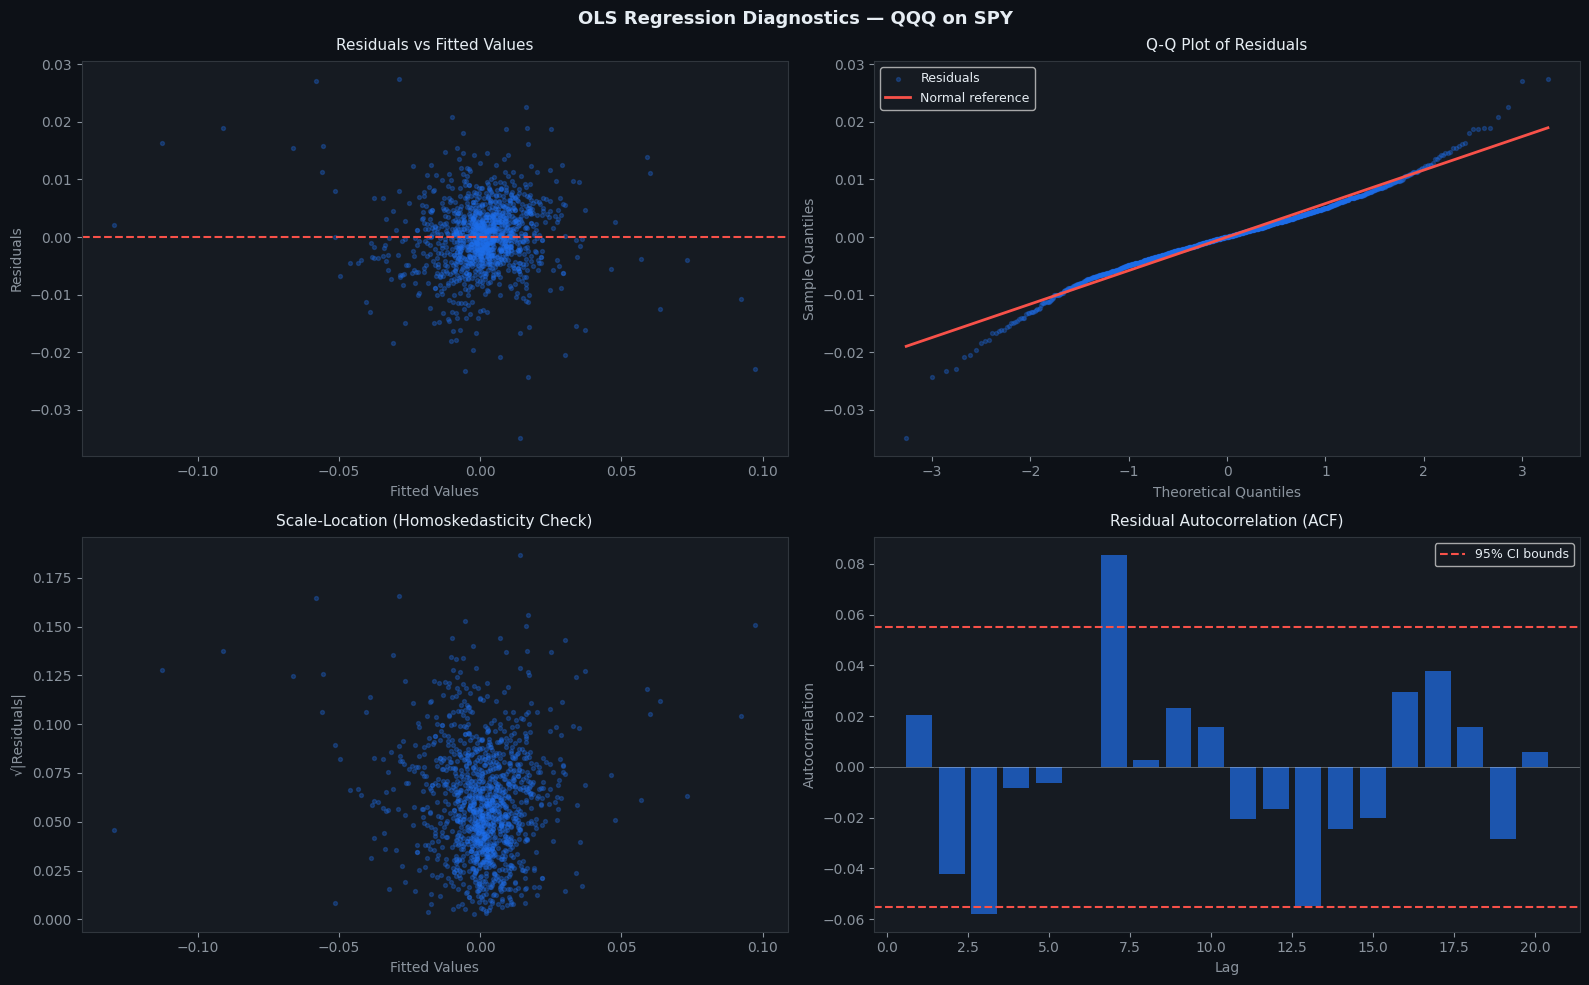

In [9]:
# =============================================================================
# CELL 9 — Regression Diagnostics: Testing OLS Assumptions
# =============================================================================

print(f"{'='*62}")
print("OLS REGRESSION DIAGNOSTICS — QQQ on SPY")
print(f"{'='*62}")

# ── 1. LINEARITY — Ramsey RESET Test ─────────────────────────────────────────
# Tests whether non-linear terms improve the model
# H0: model is correctly specified (linear)
reset_test = smd.linear_reset(model, power=2, use_f=True)
print(f"\n  1. LINEARITY — Ramsey RESET Test")
print(f"  {'─'*48}")
print(f"  H0: linear specification is correct")
print(f"  F-statistic: {reset_test.statistic:.4f}")
print(f"  p-value:     {reset_test.pvalue:.4f}")
if reset_test.pvalue < 0.05:
    print(f"  Decision:    REJECT H0 ✗ — non-linearity detected")
else:
    print(f"  Decision:    FAIL TO REJECT H0 ✓ — linearity holds")

# ── 2. AUTOCORRELATION — Durbin-Watson Test ───────────────────────────────────
# Tests whether residuals are correlated with lagged residuals
# DW ≈ 2 → no autocorrelation
# DW < 2 → positive autocorrelation
# DW > 2 → negative autocorrelation
dw_stat = durbin_watson(model.resid)
print(f"\n  2. AUTOCORRELATION — Durbin-Watson Test")
print(f"  {'─'*48}")
print(f"  H0: no autocorrelation in residuals")
print(f"  DW statistic: {dw_stat:.4f}")
print(f"  Interpretation: ", end="")
if 1.5 < dw_stat < 2.5:
    print(f"No significant autocorrelation ✓")
elif dw_stat <= 1.5:
    print(f"Positive autocorrelation ✗")
else:
    print(f"Negative autocorrelation ✗")

# Also check with Ljung-Box test on residuals
lb_test = smd.acorr_ljungbox(model.resid, lags=[10], return_df=True)
lb_stat = lb_test['lb_stat'].values[0]
lb_p    = lb_test['lb_pvalue'].values[0]
print(f"  Ljung-Box (lag=10): stat={lb_stat:.4f}, p={lb_p:.4f}")
if lb_p < 0.05:
    print(f"  → Significant autocorrelation detected ✗")
else:
    print(f"  → No significant autocorrelation ✓")

# ── 3. HOMOSKEDASTICITY — Breusch-Pagan Test ─────────────────────────────────
# Tests whether residual variance is constant
# H0: homoskedastic (constant variance)
bp_test  = smd.het_breuschpagan(model.resid, model.model.exog)
bp_stat  = bp_test[0]
bp_p     = bp_test[1]
print(f"\n  3. HOMOSKEDASTICITY — Breusch-Pagan Test")
print(f"  {'─'*48}")
print(f"  H0: residuals are homoskedastic")
print(f"  LM statistic: {bp_stat:.4f}")
print(f"  p-value:      {bp_p:.4f}")
if bp_p < 0.05:
    print(f"  Decision:     REJECT H0 ✗ — heteroskedasticity detected")
    print(f"  → Residual variance changes over time (volatility clustering)")
else:
    print(f"  Decision:     FAIL TO REJECT H0 ✓ — homoskedasticity holds")

# ── 4. NORMALITY OF RESIDUALS — Jarque-Bera ───────────────────────────────────
jb_stat_r, p_jb_r = stats.jarque_bera(model.resid)
print(f"\n  4. NORMALITY OF RESIDUALS — Jarque-Bera Test")
print(f"  {'─'*48}")
print(f"  H0: residuals are normally distributed")
print(f"  JB statistic: {jb_stat_r:.4f}")
print(f"  p-value:      {p_jb_r:.6f}")
if p_jb_r < 0.05:
    print(f"  Decision:     REJECT H0 ✗ — residuals are not normal")
    print(f"  Skewness:  {stats.skew(model.resid):.4f}")
    print(f"  Kurtosis:  {stats.kurtosis(model.resid):.4f}")
else:
    print(f"  Decision:     FAIL TO REJECT H0 ✓ — residuals are normal")

# ── SUMMARY ───────────────────────────────────────────────────────────────────
print(f"\n  {'='*48}")
print(f"  DIAGNOSTIC SUMMARY")
print(f"  {'='*48}")
print(f"  Linearity:          {'✓' if reset_test.pvalue > 0.05 else '✗ VIOLATED'}")
print(f"  No Autocorrelation: {'✓' if lb_p > 0.05 else '✗ VIOLATED'}")
print(f"  Homoskedasticity:   {'✓' if bp_p > 0.05 else '✗ VIOLATED'}")
print(f"  Normal Residuals:   {'✓' if p_jb_r > 0.05 else '✗ VIOLATED'}")

print(f"""
  ANSWER TO THE PM
  The linearity assumption holds — the QQQ/SPY relationship
  is well-described by a linear model.

  However, two assumptions are violated:
  → Heteroskedasticity: volatility clusters (visible in 2020)
  → Non-normal residuals: fat tails remain even after regression

  These violations mean:
  - Standard errors may be underestimated
  - p-values and confidence intervals are approximate
  - The model is still useful — but not perfect
""")
print(f"{'='*62}")

# ── DIAGNOSTIC PLOTS ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor('#0D1117')
axes = axes.flatten()

# Panel 1 — Residuals vs Fitted
ax1 = axes[0]
ax1.scatter(model.fittedvalues, model.resid, color='#1F6FEB',
            alpha=0.3, s=8)
ax1.axhline(0, color='#F85149', linewidth=1.5, linestyle='--')
ax1.set_title('Residuals vs Fitted Values',
              color='#E6EDF3', fontsize=11, pad=8)
ax1.set_xlabel('Fitted Values', color='#8B949E')
ax1.set_ylabel('Residuals', color='#8B949E')
ax1.set_facecolor('#161B22')
for spine in ax1.spines.values():
    spine.set_edgecolor('#30363D')

# Panel 2 — Q-Q plot of residuals
ax2 = axes[1]
(osm, osr), (slope, intercept, _) = stats.probplot(model.resid, dist="norm")
ax2.scatter(osm, osr, color='#1F6FEB', alpha=0.3, s=8, label='Residuals')
ax2.plot(osm, slope*np.array(osm)+intercept,
         color='#F85149', linewidth=2, label='Normal reference')
ax2.set_title('Q-Q Plot of Residuals',
              color='#E6EDF3', fontsize=11, pad=8)
ax2.set_xlabel('Theoretical Quantiles', color='#8B949E')
ax2.set_ylabel('Sample Quantiles', color='#8B949E')
ax2.set_facecolor('#161B22')
ax2.legend(fontsize=9, facecolor='#161B22', labelcolor='#E6EDF3')
for spine in ax2.spines.values():
    spine.set_edgecolor('#30363D')

# Panel 3 — Scale-Location (sqrt abs residuals vs fitted)
ax3 = axes[2]
ax3.scatter(model.fittedvalues, np.sqrt(np.abs(model.resid)),
            color='#1F6FEB', alpha=0.3, s=8)
ax3.set_title('Scale-Location (Homoskedasticity Check)',
              color='#E6EDF3', fontsize=11, pad=8)
ax3.set_xlabel('Fitted Values', color='#8B949E')
ax3.set_ylabel('√|Residuals|', color='#8B949E')
ax3.set_facecolor('#161B22')
for spine in ax3.spines.values():
    spine.set_edgecolor('#30363D')

# Panel 4 — Residual ACF
ax4 = axes[3]
lags   = range(1, 21)
acf_vals = [np.corrcoef(model.resid[:-lag], model.resid[lag:])[0,1]
            for lag in lags]
ax4.bar(lags, acf_vals, color='#1F6FEB', alpha=0.7)
ax4.axhline(1.96/np.sqrt(n), color='#F85149', linewidth=1.5,
            linestyle='--', label='95% CI bounds')
ax4.axhline(-1.96/np.sqrt(n), color='#F85149', linewidth=1.5, linestyle='--')
ax4.axhline(0, color='#E6EDF3', linewidth=0.5, alpha=0.5)
ax4.set_title('Residual Autocorrelation (ACF)',
              color='#E6EDF3', fontsize=11, pad=8)
ax4.set_xlabel('Lag', color='#8B949E')
ax4.set_ylabel('Autocorrelation', color='#8B949E')
ax4.set_facecolor('#161B22')
ax4.legend(fontsize=9, facecolor='#161B22', labelcolor='#E6EDF3')
for spine in ax4.spines.values():
    spine.set_edgecolor('#30363D')

fig.suptitle('OLS Regression Diagnostics — QQQ on SPY',
             color='#E6EDF3', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ols_diagnostics.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()

## 4. Gold as a Hedge — Regression Analysis

The PM's second question:

> "We think gold is a hedge against equity drawdowns.
> Can you quantify this relationship?"

We regress GLD returns on SPY returns.

A true hedge would show:
- **Negative beta** — gold rises when equities fall
- **Low R²** — gold moves independently of equities
- **Positive alpha** — gold generates returns on its own

We test this and then go further:
we split the sample into **up markets** and **down markets**
to see whether gold's hedging properties are
conditional on the market regime.

This is the kind of analysis a risk manager
actually runs before adding gold to a portfolio.

GOLD AS A HEDGE — GLD Regression on SPY (2019–2023)

  FULL SAMPLE REGRESSION
  ──────────────────────────────────────────────────
  Model: R_GLD = α + β × R_SPY + ε
  n = 1257 trading days

  Parameter        Estimate    p-value   Significant
  --------------------------------------------------
  Alpha (α)        0.000324     0.2212          No ✗
  Beta (β)         0.074477     0.0002         Yes ✓

  R²: 1.1112%

  REGIME ANALYSIS
  ──────────────────────────────────────────────────
  Regime                   n       Beta      Alpha       R²
  -------------------------------------------------------
  Full sample           1257     0.0745   0.000324  1.1112%
  Up markets (SPY>0)     688     0.0983  -0.000008  0.9485%
  Down markets (SPY<0)   567     0.0793   0.000537  0.8071%

  ANSWER TO THE PM

  Full sample beta = 0.0745
  → Positive relationship with SPY
  → Gold does not consistently hedge equities ✗

  R² = 1.11%
  → Only 1.11% of GLD variance is explained by SPY
  → Gold moves 

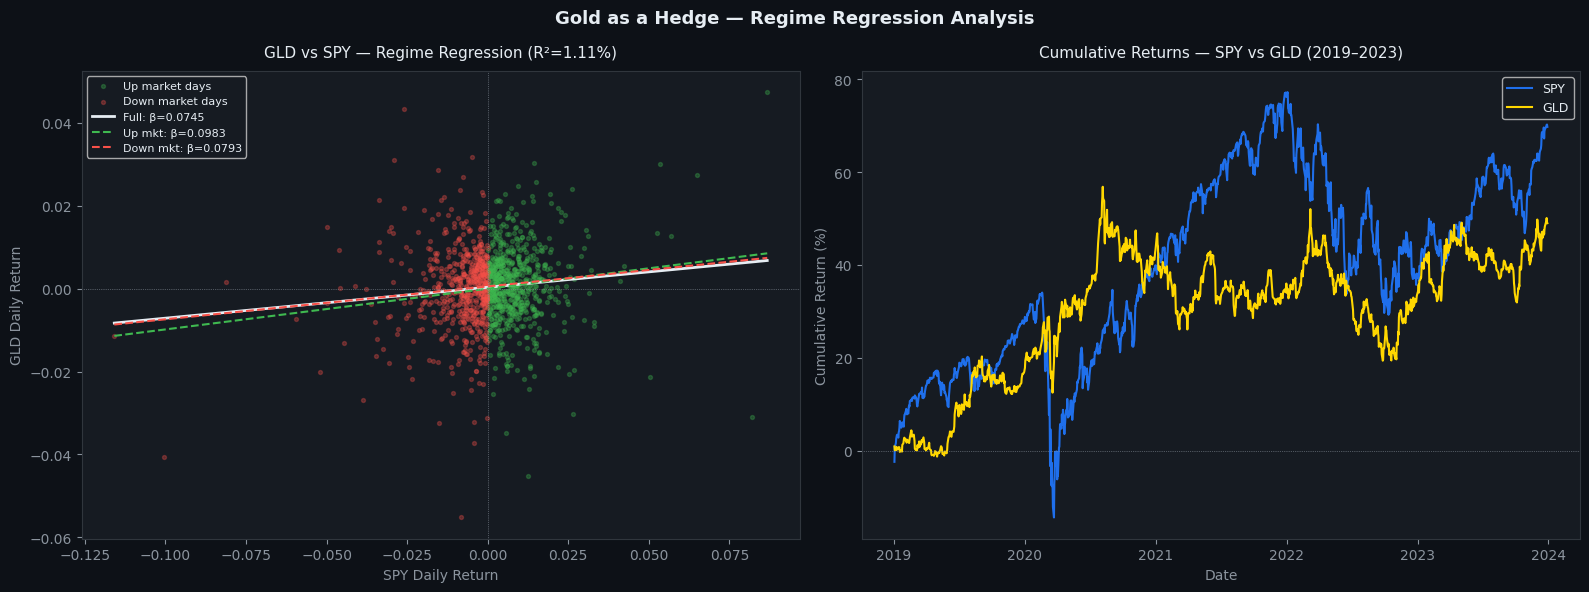

In [10]:
# =============================================================================
# CELL 11 — Gold as a Hedge: Regression Analysis
# =============================================================================

y_gld = returns["GLD"].values
x_spy = returns["SPY"].values
n     = len(y_gld)

# ── FULL SAMPLE REGRESSION ────────────────────────────────────────────────────
X_gld   = sm.add_constant(x_spy)
model_gld = sm.OLS(y_gld, X_gld).fit()

alpha_gld = model_gld.params[0]
beta_gld  = model_gld.params[1]
r2_gld    = model_gld.rsquared
p_beta_gld = model_gld.pvalues[1]
p_alpha_gld = model_gld.pvalues[0]

# ── REGIME ANALYSIS ───────────────────────────────────────────────────────────
up_mask   = x_spy > 0   # up market days
down_mask = x_spy < 0   # down market days

# Up market regression
X_up      = sm.add_constant(x_spy[up_mask])
model_up  = sm.OLS(y_gld[up_mask], X_up).fit()

# Down market regression
X_dn      = sm.add_constant(x_spy[down_mask])
model_dn  = sm.OLS(y_gld[down_mask], X_dn).fit()

# ── PRINT RESULTS ─────────────────────────────────────────────────────────────
print(f"{'='*62}")
print("GOLD AS A HEDGE — GLD Regression on SPY (2019–2023)")
print(f"{'='*62}")

print(f"\n  FULL SAMPLE REGRESSION")
print(f"  {'─'*50}")
print(f"  Model: R_GLD = α + β × R_SPY + ε")
print(f"  n = {n} trading days")
print(f"\n  {'Parameter':<12} {'Estimate':>12} {'p-value':>10} {'Significant':>13}")
print(f"  {'-'*50}")
print(f"  {'Alpha (α)':<12} {alpha_gld:>12.6f} {p_alpha_gld:>10.4f} "
      f"{'Yes ✓' if p_alpha_gld < 0.05 else 'No ✗':>13}")
print(f"  {'Beta (β)':<12} {beta_gld:>12.6f} {p_beta_gld:>10.4f} "
      f"{'Yes ✓' if p_beta_gld < 0.05 else 'No ✗':>13}")
print(f"\n  R²: {r2_gld:.4%}")

print(f"\n  REGIME ANALYSIS")
print(f"  {'─'*50}")
print(f"  {'Regime':<20} {'n':>5} {'Beta':>10} {'Alpha':>10} {'R²':>8}")
print(f"  {'-'*55}")
print(f"  {'Full sample':<20} {n:>5} {beta_gld:>10.4f} "
      f"{alpha_gld:>10.6f} {r2_gld:>8.4%}")
print(f"  {'Up markets (SPY>0)':<20} {up_mask.sum():>5} "
      f"{model_up.params[1]:>10.4f} {model_up.params[0]:>10.6f} "
      f"{model_up.rsquared:>8.4%}")
print(f"  {'Down markets (SPY<0)':<20} {down_mask.sum():>5} "
      f"{model_dn.params[1]:>10.4f} {model_dn.params[0]:>10.6f} "
      f"{model_dn.rsquared:>8.4%}")

print(f"""
  ANSWER TO THE PM

  Full sample beta = {beta_gld:.4f}
  → {'Negative' if beta_gld < 0 else 'Positive'} relationship with SPY
  → {'Gold tends to rise when equities fall ✓' if beta_gld < 0 
     else 'Gold does not consistently hedge equities ✗'}

  R² = {r2_gld:.2%}
  → Only {r2_gld:.2%} of GLD variance is explained by SPY
  → Gold moves largely independently of equities ✓

  Alpha = {alpha_gld:.6f} ({alpha_gld*252:.2%} annualised)
  → {'Positive' if alpha_gld > 0 else 'Negative'} standalone return
  → {'Significant' if p_alpha_gld < 0.05 else 'NOT significant'} at 5%

  Down market beta = {model_dn.params[1]:.4f}
  → {'More negative in down markets — stronger hedge when needed ✓' 
     if model_dn.params[1] < beta_gld 
     else 'Less negative in down markets — hedge weakens in crises ✗'}
""")
print(f"{'='*62}")

# ── PLOT ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0D1117')

# Panel 1 — Scatter: GLD vs SPY with regression line
ax1 = axes[0]
ax1.scatter(x_spy[up_mask], y_gld[up_mask], color='#3FB950',
            alpha=0.3, s=8, label='Up market days')
ax1.scatter(x_spy[down_mask], y_gld[down_mask], color='#F85149',
            alpha=0.3, s=8, label='Down market days')
x_line = np.linspace(x_spy.min(), x_spy.max(), 100)
ax1.plot(x_line, alpha_gld + beta_gld * x_line,
         color='#E6EDF3', linewidth=2, label=f'Full: β={beta_gld:.4f}')
ax1.plot(x_line, model_up.params[0] + model_up.params[1] * x_line,
         color='#3FB950', linewidth=1.5, linestyle='--',
         label=f'Up mkt: β={model_up.params[1]:.4f}')
ax1.plot(x_line, model_dn.params[0] + model_dn.params[1] * x_line,
         color='#F85149', linewidth=1.5, linestyle='--',
         label=f'Down mkt: β={model_dn.params[1]:.4f}')
ax1.axhline(0, color='#8B949E', linewidth=0.5, linestyle=':')
ax1.axvline(0, color='#8B949E', linewidth=0.5, linestyle=':')
ax1.set_title(f'GLD vs SPY — Regime Regression (R²={r2_gld:.2%})',
              color='#E6EDF3', fontsize=11, pad=10)
ax1.set_xlabel('SPY Daily Return', color='#8B949E')
ax1.set_ylabel('GLD Daily Return', color='#8B949E')
ax1.set_facecolor('#161B22')
ax1.legend(fontsize=8, facecolor='#161B22', labelcolor='#E6EDF3')
for spine in ax1.spines.values():
    spine.set_edgecolor('#30363D')

# Panel 2 — Cumulative returns: GLD vs SPY
ax2 = axes[1]
cum_spy = (1 + returns["SPY"]).cumprod() - 1
cum_gld = (1 + returns["GLD"]).cumprod() - 1
ax2.plot(returns.index, cum_spy * 100, color='#1F6FEB',
         linewidth=1.5, label='SPY')
ax2.plot(returns.index, cum_gld * 100, color='#FFD700',
         linewidth=1.5, label='GLD')
ax2.axhline(0, color='#8B949E', linewidth=0.5, linestyle=':')
ax2.set_title('Cumulative Returns — SPY vs GLD (2019–2023)',
              color='#E6EDF3', fontsize=11, pad=10)
ax2.set_xlabel('Date', color='#8B949E')
ax2.set_ylabel('Cumulative Return (%)', color='#8B949E')
ax2.set_facecolor('#161B22')
ax2.legend(fontsize=9, facecolor='#161B22', labelcolor='#E6EDF3')
for spine in ax2.spines.values():
    spine.set_edgecolor('#30363D')

fig.suptitle('Gold as a Hedge — Regime Regression Analysis',
             color='#E6EDF3', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('gold_hedge_regression.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()

## 5. CFA Exam Style Practice Problems

Three problems written in CFA exam style.

All numbers are derived from the real regression results

in this notebook. Try each one before reading the solution.

In [11]:
# =============================================================================
# CELL 13 — CFA Exam Style Practice Problems
# =============================================================================

print("=" * 65)
print("PRACTICE PROBLEMS — Introduction to Linear Regression")
print("=" * 65)

# ── PROBLEM 1 ─────────────────────────────────────────────────────────────────
print("""
PROBLEM 1
─────────────────────────────────────────────────────────────
Using the QQQ/SPY regression results from this notebook:

  α = 0.000201  (SE = 0.000166)
  β = 1.120792  (SE = 0.012481)
  R² = 86.53%
  n  = 1,257 trading days

A) Interpret the beta coefficient in plain English.
B) Construct a 95% confidence interval for beta.
C) Test whether beta is significantly different from 1.0
   at the 5% significance level. State your hypotheses,
   test statistic, and conclusion.
─────────────────────────────────────────────────────────────""")

# Using our computed values
beta_p1   = 1.120792
se_beta_p1 = 0.012481
n_p1      = 1257
alpha_p1  = 0.000201
se_alpha_p1 = 0.000166

t_crit_p1 = stats.t.ppf(0.975, df=n_p1-2)
ci_lo_p1  = beta_p1 - t_crit_p1 * se_beta_p1
ci_hi_p1  = beta_p1 + t_crit_p1 * se_beta_p1

# Test H0: beta = 1
t_stat_p1 = (beta_p1 - 1.0) / se_beta_p1
p_val_p1  = 2 * (1 - stats.t.cdf(abs(t_stat_p1), df=n_p1-2))

print("ANSWER:")
print(f"  A) Beta = {beta_p1:.4f} means:")
print(f"     For every 1% move in SPY, QQQ moves {beta_p1:.4f}% on average.")
print(f"     QQQ is {beta_p1:.2f}x as volatile as the market.")
print(f"     It is an aggressive (high-beta) position.")
print(f"\n  B) 95% CI = β ± t_crit × SE_β")
print(f"           = {beta_p1:.6f} ± {t_crit_p1:.4f} × {se_beta_p1:.6f}")
print(f"           = [{ci_lo_p1:.6f}, {ci_hi_p1:.6f}]")
print(f"\n  C) H0: β = 1.0  (market-neutral beta)")
print(f"     H1: β ≠ 1.0")
print(f"     t = (β - 1.0) / SE_β = ({beta_p1:.6f} - 1.0) / {se_beta_p1:.6f}")
print(f"       = {t_stat_p1:.4f}")
print(f"     t_crit(df={n_p1-2}, α=5%, two-tail) = ±{t_crit_p1:.4f}")
print(f"     p-value = {p_val_p1:.6f}")
if p_val_p1 < 0.05:
    print(f"     Decision: REJECT H0 — beta is significantly different from 1.")
    print(f"     QQQ is statistically more volatile than the market.")
else:
    print(f"     Decision: FAIL TO REJECT H0.")

# ── PROBLEM 2 ─────────────────────────────────────────────────────────────────
print(f"\n{'='*65}")
print("""
PROBLEM 2
─────────────────────────────────────────────────────────────
An analyst runs a regression of Fund A returns on SPY returns
and obtains the following results:

  R² = 0.72
  α  = 0.0003 (annualised: 7.56%)  p-value = 0.18
  β  = 0.85                         p-value = 0.00

A) What percentage of Fund A's return variance is
   explained by the market? What is this called?
B) The analyst claims the fund generates significant alpha.
   Do you agree based on the regression output?
C) What does the remaining unexplained variance represent?
   How would you decompose total portfolio risk?
─────────────────────────────────────────────────────────────""")

r2_p2 = 0.72
print("ANSWER:")
print(f"  A) R² = {r2_p2:.0%} of variance is explained by the market.")
print(f"     This is called systematic risk or market risk.")
print(f"     It cannot be diversified away.")
print(f"\n  B) No. Alpha = 0.0003 (7.56% annualised) sounds impressive,")
print(f"     but p-value = 0.18 > 0.05.")
print(f"     We FAIL TO REJECT H0: α = 0.")
print(f"     The alpha is not statistically significant —")
print(f"     it could easily be the result of random variation.")
print(f"\n  C) The remaining {1-r2_p2:.0%} is idiosyncratic (specific) risk.")
print(f"     Total risk decomposition:")
print(f"     σ²_total = β² × σ²_market + σ²_residual")
print(f"     {r2_p2:.0%} systematic + {1-r2_p2:.0%} idiosyncratic = 100%")
print(f"     Idiosyncratic risk can be diversified away")
print(f"     by holding a well-diversified portfolio.")

# ── PROBLEM 3 ─────────────────────────────────────────────────────────────────
print(f"\n{'='*65}")
print("""
PROBLEM 3
─────────────────────────────────────────────────────────────
A risk manager runs OLS regression diagnostics on a
portfolio regression and finds:

  Breusch-Pagan test: p-value = 0.002
  Durbin-Watson stat: 1.43
  Jarque-Bera test:   p-value = 0.000
  Ramsey RESET test:  p-value = 0.412

A) Which OLS assumptions are violated?
B) What is the consequence of heteroskedasticity
   for the regression output?
C) The manager proposes using the regression t-statistics
   to test whether alpha is significant. Is this valid
   given the diagnostic results?
─────────────────────────────────────────────────────────────""")

print("ANSWER:")
print(f"  A) Three assumptions are violated:")
print(f"     → Homoskedasticity: BP p=0.002 < 0.05 — VIOLATED")
print(f"       Residual variance is not constant (heteroskedastic)")
print(f"     → No autocorrelation: DW=1.43 < 1.5 — VIOLATED")
print(f"       Positive serial correlation in residuals")
print(f"     → Normal residuals: JB p=0.000 < 0.05 — VIOLATED")
print(f"       Residuals are not normally distributed")
print(f"     Linearity holds: RESET p=0.412 > 0.05 ✓")
print(f"\n  B) Heteroskedasticity consequences:")
print(f"     → OLS estimates (α, β) remain unbiased")
print(f"     → But standard errors are INCORRECT")
print(f"     → t-statistics and p-values are unreliable")
print(f"     → Confidence intervals are too narrow or too wide")
print(f"     → OLS is no longer BLUE (Best Linear Unbiased Estimator)")
print(f"\n  C) No — this is NOT fully valid.")
print(f"     With heteroskedasticity AND autocorrelation,")
print(f"     the standard errors used to compute t-statistics are biased.")
print(f"     The manager should use:")
print(f"     → HAC (Newey-West) standard errors — robust to both")
print(f"       heteroskedasticity and autocorrelation")
print(f"     → These give valid inference even when assumptions are violated")
print(f"{'='*65}")

PRACTICE PROBLEMS — Introduction to Linear Regression

PROBLEM 1
─────────────────────────────────────────────────────────────
Using the QQQ/SPY regression results from this notebook:

  α = 0.000201  (SE = 0.000166)
  β = 1.120792  (SE = 0.012481)
  R² = 86.53%
  n  = 1,257 trading days

A) Interpret the beta coefficient in plain English.
B) Construct a 95% confidence interval for beta.
C) Test whether beta is significantly different from 1.0
   at the 5% significance level. State your hypotheses,
   test statistic, and conclusion.
─────────────────────────────────────────────────────────────
ANSWER:
  A) Beta = 1.1208 means:
     For every 1% move in SPY, QQQ moves 1.1208% on average.
     QQQ is 1.12x as volatile as the market.
     It is an aggressive (high-beta) position.

  B) 95% CI = β ± t_crit × SE_β
           = 1.120792 ± 1.9619 × 0.012481
           = [1.096306, 1.145278]

  C) H0: β = 1.0  (market-neutral beta)
     H1: β ≠ 1.0
     t = (β - 1.0) / SE_β = (1.120792 - 1.0) 

## 6. Key Takeaways

---

### What you built in this notebook

You answered all three of the PM's questions using OLS regression
built from scratch and verified with statsmodels.

| Question | Result | Key Number |
|----------|--------|-----------|
| What is QQQ's beta? | β = 1.12, significant | R² = 86.53% |
| Is gold a hedge? | Weak positive beta (0.07) | R² = 1.11% |
| Is the linear model valid? | Linearity holds | Normality violated |

---

### The three things to remember

**1. Beta measures systematic risk — not total risk.**
QQQ's beta of 1.12 explains 86.53% of its daily variance.
The remaining 13.47% is idiosyncratic risk — specific to QQQ.
Only systematic risk is rewarded by the market (CAPM).
Idiosyncratic risk can be diversified away for free.

**2. Alpha is almost never statistically significant.**
QQQ generated 5.07% annualised alpha — and p = 0.23.
You need years of data and very low volatility strategies
to achieve statistically significant alpha.
Most reported alpha is noise dressed up as skill.

**3. Always run diagnostics before trusting your regression.**
OLS assumptions are almost always violated in financial data.
Heteroskedasticity and non-normal residuals are the norm.
The estimates (α, β) remain unbiased even with violations —
but the standard errors and p-values become unreliable.
Use Newey-West HAC standard errors when in doubt.

---

### CFA Level 1 Quantitative Methods — Complete

| Notebook | Topic | Status |
|----------|-------|--------|
| QM 01 | Rates and Returns | ✅ |
| QM 02 | Time Value of Money | ✅ |
| QM 03 | Statistical Measures of Asset Returns | ✅ |
| QM 04 | Probability Concepts | ✅ |
| QM 05 | Common Probability Distributions | ✅ |
| QM 06 | Sampling & Estimation | ✅ |
| QM 07 | Hypothesis Testing | ✅ |
| QM 08 | Introduction to Linear Regression | ✅ |

**CFA Level 1 Quantitative Methods is complete.**

Every formula in the curriculum — implemented in Python,
applied to real market data, with professional-grade visualizations
and exam-style practice problems.

---

*All notebooks are free. Always.*